### Gradient Boosting and XGBoost Models 

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
import math
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('df4_final_preparation.csv')


# --- 1. Veri bölme ---
#train, test = train_test_split(df, test_size=0.2, random_state=42)

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df, groups=df['District']))
train, test = df.iloc[train_idx], df.iloc[test_idx]


# --- 2. Target encoding (sızıntısız) ---
dist_map = train.groupby('District')['Price'].mean()
neigh_map = train.groupby('Neighborhood')['Price'].mean()

train.loc[:, 'District_Encoded'] = train['District'].map(dist_map)
test.loc[:, 'District_Encoded'] = test['District'].map(dist_map)

train.loc[:, 'Neighborhood_Encoded'] = train['Neighborhood'].map(neigh_map)
test.loc[:, 'Neighborhood_Encoded'] = test['Neighborhood'].map(neigh_map)

global_mean = train['Price'].mean()
test.loc[:, 'District_Encoded'] = test['District_Encoded'].fillna(global_mean)
test.loc[:, 'Neighborhood_Encoded'] = test['Neighborhood_Encoded'].fillna(global_mean)

# --- 3. Model girdilerini hazırla ---
X_train = train.drop(columns=['Price', 'District', 'Neighborhood',"Ground_Risk"])
y_train = train['Price']
X_test = test.drop(columns=['Price', 'District', 'Neighborhood',"Ground_Risk"])
y_test = test['Price']

# --- 4. Gradient Boosting ---
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting:")
print(f"  R²: {r2_score(y_test, y_pred_gb):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_gb):,.0f} TL")
print(f"  RMSE: {math.sqrt(mean_squared_error(y_test, y_pred_gb)):,.0f} TL")

# --- 5. XGBoost ---
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("\nXGBoost:")
print(f"  R²: {r2_score(y_test, y_pred_xgb):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_xgb):,.0f} TL")
print(f"  RMSE: {math.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f} TL")

# --- 6. Örnek tahmin ---
sample = X_test.iloc[[0]]  # test setinden örnek bir satır
pred_price = xgb_model.predict(sample)[0]
print(f"\nÖrnek tahmin edilen fiyat: {pred_price:,.0f} TL")


Gradient Boosting:
  R²: 0.9906
  MAE: 504,396 TL
  RMSE: 1,617,193 TL

XGBoost:
  R²: 0.9465
  MAE: 735,518 TL
  RMSE: 3,862,968 TL

Örnek tahmin edilen fiyat: 7,232,734 TL


In [9]:
sample

,Total_Room,Bathroom_Count,Net_M2,Number_of_Floors,Floor,Furnished_Status,Is_New_Building,Is_Occupied,Is_Swap_Available,In_a_Complex,...,Heating_Soba-Geleneksel,Heating_Yerden Isıtma-Modern,Tapu_Diger/Riskli,Tapu_Hisseli Mülkiyet,Tapu_Kat İrtifakı,Tapu_Tam Mülkiyet,Building_Type_Encoded,District_Encoded,Neighborhood_Encoded,Price_Per_Sqrft
1,4,1.0,120,3,2.0,0,0,1,0,0,...,0,0,0,0,0,0,1,1.102686e+07,1.102686e+07,62500.0


## Saving the XGBoost Model

In [20]:
# import joblib

# # Model ve encoding haritalarını kaydet
# joblib.dump(xgb_model, "model.pkl")
# joblib.dump(dist_map, "dist_map.pkl")
# joblib.dump(neigh_map, "neigh_map.pkl")
# joblib.dump(global_mean, "global_mean.pkl")

# print("Model ve mapping dosyaları kaydedildi.")

## prediction_data.pkl

### Creating "prediction_data.pkl"

In [21]:
# import pickle

# # Dropdown menüler için ilçe-mahalle hiyerarşisini de oluşturalım
# location_hierarchy = df.groupby('District')['Neighborhood'].apply(lambda x: sorted(x.unique().tolist())).to_dict()
# for district in location_hierarchy:
#     location_hierarchy[district].sort()

# # Tüm bu verileri tek bir sözlükte toplayalım
# prediction_data = {
#     'dist_map': dist_map,
#     'neigh_map': neigh_map,
#     'global_mean': global_mean,
#     'location_hierarchy': location_hierarchy,
#     'districts': sorted(df['District'].unique())
# }

# # Bu sözlüğü pickle ile kaydet
# # Bu dosyayı app.py'nin yanına kopyalayacaksınız.
# with open('prediction_data.pkl', 'wb') as f:
#     pickle.dump(prediction_data, f)

# print("Tahmin verileri 'prediction_data.pkl' dosyasına başarıyla kaydedildi.")

### Updating "prediction_data.pkl"

In [22]:
# # update_pickle.py (DÜZELTİLMİŞ VERSİYON)
# import pandas as pd
# import pickle

# print("Pickle güncelleme işlemi başlıyor...")

# # 2. Her satır için gerçek birim metrekare fiyatını hesapla
# # (Eğitim verisindeki gerçek fiyat / net metrekare)
# df['Gercek_Birim_Fiyat'] = df['Price'] / df['Net_M2']

# # 3. Mahalle bazında ortalama birim fiyatı hesapla
# # DÜZELTME: Sizin 'Neighborhood' sütununuz zaten 'İlçe_Mahalle' formatında olduğu için
# # ekstra bir birleştirme işlemi yapmıyoruz. Doğrudan o sütunu kullanıyoruz.
# sqrft_map = df.groupby('Neighborhood')['Gercek_Birim_Fiyat'].mean().to_dict()

# # Genel ortalama birim fiyat (bilinmeyen mahalleler için yedek)
# global_sqrft_mean = df['Gercek_Birim_Fiyat'].mean()

# # Kontrol için ekrana yazdıralım
# test_key = 'Sarıyer_Maslak Mah.'
# print(f"\nKONTROL:")
# print(f"Aranan Anahtar: '{test_key}'")
# print(f"Bulunan Değer: {sqrft_map.get(test_key, 'Hala Bulunamadı!')}")

# # 4. Mevcut pickle dosyasını yükle ve güncelle
# try:
#     with open('prediction_data.pkl', 'rb') as f:
#         data = pickle.load(f)
    
#     # Yeni haritayı sözlüğe ekle
#     data['sqrft_map'] = sqrft_map
#     data['global_sqrft_mean'] = global_sqrft_mean

#     # 5. Dosyayı tekrar kaydet
#     with open('prediction_data.pkl', 'wb') as f:
#         pickle.dump(data, f)

#     print("\nBAŞARILI: prediction_data.pkl güncellendi! 'sqrft_map' doğru şekilde eklendi.")

# except FileNotFoundError:
#     print("HATA: 'prediction_data.pkl' dosyası bulunamadı.")

### Update for "Ground_Risk"

In [23]:
# # update_pickle.py (Risk Haritası Eklenmiş Versiyon)
# import pandas as pd
# import pickle

# print("Pickle güncelleme ve Risk Haritası oluşturma işlemi başlıyor...")

# try:
#     # 2. Mevcut Pickle'ı Yükle
#     with open('prediction_data.pkl', 'rb') as f:
#         data = pickle.load(f)

#     # 3. Risk Haritası Oluştur (Mahalle -> Deprem Riski)
#     # Verisetinde sütun adı 'Ground_Risk' olarak görünüyor.
#     # Her mahalle için ortalama risk puanını alıyoruz (genelde mahalle içinde aynıdır)
#     risk_map = df.groupby('Neighborhood')['Ground_Risk'].mean().to_dict()
    
#     # Genel ortalama risk (Bilinmeyen mahalleler için)
#     global_risk_mean = df['Ground_Risk'].mean()

#     # 4. Veriyi Pickle Sözlüğüne Ekle
#     data['risk_map'] = risk_map
#     data['global_risk_mean'] = global_risk_mean
    
#     # sqrft_map daha önce eklenmemişse onu da tekrar garantiye alalım
#     df['Gercek_Birim_Fiyat'] = df['Price'] / df['Net_M2']
#     data['sqrft_map'] = df.groupby('Neighborhood')['Gercek_Birim_Fiyat'].mean().to_dict()
#     data['global_sqrft_mean'] = df['Gercek_Birim_Fiyat'].mean()

#     # 5. Dosyayı Kaydet
#     with open('prediction_data.pkl', 'wb') as f:
#         pickle.dump(data, f)

#     print(f"BAŞARILI: 'risk_map' eklendi. (Örnek Risk Değeri: {list(risk_map.values())[0]:.2f})")

# except FileNotFoundError as e:
#     print(f"HATA: Dosya bulunamadı -> {e}")
# except KeyError as e:
#     print(f"HATA: Sütun bulunamadı -> {e}. Lütfen CSV'deki sütun adının 'Ground_Risk' olduğundan emin olun.")

Pickle güncelleme ve Risk Haritası oluşturma işlemi başlıyor...
BAŞARILI: 'risk_map' eklendi. (Örnek Risk Değeri: 0.53)


# Creating explore_data.pkl for "Explore Page"

In [1]:
# import pandas as pd
# import pickle

# # Veri setini yükle
# df_explore = pd.read_csv('df4_final_preparation.csv')

# # 1. Tüm veri üzerinden İlçe bazlı ortalama fiyatlar (Dictionary formatında)
# dist_means_full = df_explore.groupby('District')['Price'].mean().to_dict()

# # 2. Tüm veri üzerinden Mahalle bazlı ortalama fiyatlar
# # Not: CSV'nizde mahalleler zaten "İlçe_Mahalle" formatında olduğu için direkt grupluyoruz
# neigh_means_full = df_explore.groupby('Neighborhood')['Price'].mean().to_dict()

# # 3. Explore sayfası için gereken verileri paketle
# explore_data = {
#     'dist_map_full': dist_means_full,
#     'neigh_map_full': neigh_means_full
# }

# # .pkl dosyası olarak kaydet
# with open('explore_data.pkl', 'wb') as f:
#     pickle.dump(explore_data, f)

# print("explore_data.pkl başarıyla oluşturuldu. Tüm ilçe ve mahalleler eklendi.")

explore_data.pkl başarıyla oluşturuldu. Tüm ilçe ve mahalleler eklendi.


## Feature Importance

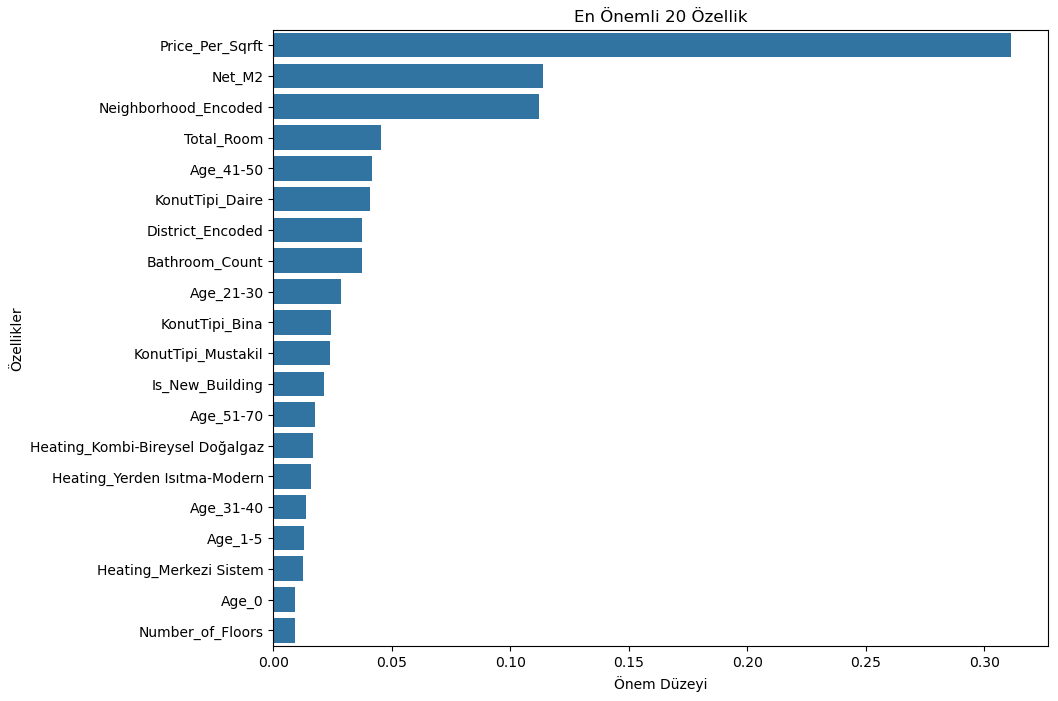

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Modelin özellik önemlerini al
feature_importances = xgb_model.feature_importances_

# Özellik isimleri ile önemlerini bir DataFrame'de birleştir
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# En önemli 20 özelliği görselleştir
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title('En Önemli 20 Özellik')
plt.xlabel('Önem Düzeyi')
plt.ylabel('Özellikler')
plt.show()

## Tahmin Test

### Tahmin

In [25]:
# --- 7. Yeni ve Belirli Bir Örnek İçin Tahmin ---

# Modelin eğitildiği X_train'deki sütun sırasını alalım.
# Bu, yeni oluşturacağımız örnek verinin sütun sırasının modelle uyumlu olmasını sağlar.
feature_columns = X_train.columns

# Tahmin edilecek evin özelliklerini bir sözlük yapısında tanımlayalım.
yeni_ev_ozellikleri = {
    # Sizin belirttiğiniz özellikler:
    'Total_Room': 3,
    'Net_M2': 100,
    'Number_of_Floors': 16,
    'Floor': 1.0,
    'Bathroom_Count': 2.0,

    # Varsayımsal olarak doldurulan diğer özellikler:
    # Bu değerleri kendi senaryonuza göre değiştirebilirsiniz.
    'Furnished_Status': 0,          # Eşyasız
    'Is_New_Building': 1,           # Yeni bina
    'Is_Occupied': 0,               # Mülk sahibi oturmuyor / Boş
    'Is_Swap_Available': 0,         # Takasa uygun değil
    'In_a_Complex': 1,              # Site içinde
    'Loan_Eligibility': 1,          # Krediye uygun
    'KonutTipi_Bina': 0,
    'KonutTipi_Daire': 1,           # Konut tipi: Daire
    'KonutTipi_Kooperatif': 0,
    'KonutTipi_Mustakil': 0,
    'KonutTipi_Yali': 0,
    'Age_0': 0,
    'Age_1-5': 1,                   # Bina yaşı: 1-5 yıl
    'Age_6-10': 0,
    'Age_11-20': 0,
    'Age_21-30': 0,
    'Age_31-40': 0,
    'Age_41-50': 0,
    'Age_51-70': 0,
    'Heating_Diger-Belirsiz': 0,
    'Heating_Kombi-Bireysel Doğalgaz': 0,
    'Heating_Merkezi Sistem': 1,    # Isınma tipi: Merkezi
    'Heating_Soba-Geleneksel': 0,
    'Heating_Yerden Isıtma-Modern': 0,
    'Tapu_Diger/Riskli': 0,
    'Tapu_Hisseli Mülkiyet': 0,
    'Tapu_Kat İrtifakı': 0,
    'Tapu_Tam Mülkiyet': 1,         # Tapu Durumu: Kat Mülkiyetli
    'Building_Type_Encoded': 1,     # Bina tipinin kodlanmış hali (varsayımsal)
}

# 1. Yeni örneği bir DataFrame'e dönüştürelim
sample_df = pd.DataFrame([yeni_ev_ozellikleri])

# 2. 'District' ve 'Neighborhood' için Target Encoding yapalım
# Eğitim setinden (train) oluşturduğumuz haritaları (map) kullanıyoruz.
# Eğer haritada bu ilçe/mahalle yoksa, genel ortalamayı (global_mean) kullanırız.
sample_df['District_Encoded'] = dist_map.get('Sarıyer', global_mean)
sample_df['Neighborhood_Encoded'] = neigh_map.get('Sarıyer_Maslak Mah.', global_mean)

# 3. 'Price_Per_Sqrft' (Metrekare Fiyatı) özelliğini hesaplayalım
# Bu özellik model eğitiminde kullanıldığı için tahmin örneğinde de olmalıdır.
# En mantıklı yaklaşım, mahallenin ortalama metrekare fiyatını kullanmaktır.
# Mahallenin ortalama fiyatını net metrekareye bölerek bu değeri tahmin edebiliriz.

ortalama_mahalle_fiyati = neigh_map.get('Sarıyer_Maslak Mah.', global_mean)
sample_df['Price_Per_Sqrft'] = ortalama_mahalle_fiyati / sample_df['Net_M2']


# 4. Sütunların sırasını modelin beklediği sırayla eşleştirelim
sample_df = sample_df[feature_columns]


# 5. XGBoost modelini kullanarak fiyat tahmini yapalım
predicted_price_new = xgb_model.predict(sample_df)[0]

print("\n--- Yeni Örnek İçin Tahmin ---")
print(f"Belirtilen özelliklere sahip evin XGBoost modeliyle tahmin edilen fiyatı: {predicted_price_new:,.0f} TL")


--- Yeni Örnek İçin Tahmin ---
Belirtilen özelliklere sahip evin XGBoost modeliyle tahmin edilen fiyatı: 10,830,262 TL


### 2. Tahmin

In [26]:
# --- 7. Yeni ve Belirli Bir Örnek İçin Tahmin ---

# Modelin eğitildiği X_train'deki sütun sırasını alalım.
# Bu, yeni oluşturacağımız örnek verinin sütun sırasının modelle uyumlu olmasını sağlar.
feature_columns = X_train.columns

# Tahmin edilecek evin özelliklerini bir sözlük yapısında tanımlayalım.
yeni_ev_ozellikleri = {
    # Sizin belirttiğiniz özellikler:
    'Total_Room': 3,
    'Net_M2': 100,
    'Number_of_Floors': 16,
    'Floor': 1.0,
    'Bathroom_Count': 2.0,

    # Varsayımsal olarak doldurulan diğer özellikler:
    # Bu değerleri kendi senaryonuza göre değiştirebilirsiniz.
    'Furnished_Status': 0,          # Eşyasız
    'Is_New_Building': 1,           # Yeni bina
    'Is_Occupied': 0,               # Mülk sahibi oturmuyor / Boş
    'Is_Swap_Available': 0,         # Takasa uygun değil
    'In_a_Complex': 1,              # Site içinde
    'Loan_Eligibility': 1,          # Krediye uygun
    'KonutTipi_Bina': 0,
    'KonutTipi_Daire': 1,           # Konut tipi: Daire
    'KonutTipi_Kooperatif': 0,
    'KonutTipi_Mustakil': 0,
    'KonutTipi_Yali': 0,
    'Age_0': 0,
    'Age_1-5': 1,                   # Bina yaşı: 1-5 yıl
    'Age_6-10': 0,
    'Age_11-20': 0,
    'Age_21-30': 0,
    'Age_31-40': 0,
    'Age_41-50': 0,
    'Age_51-70': 0,
    'Heating_Diger-Belirsiz': 0,
    'Heating_Kombi-Bireysel Doğalgaz': 0,
    'Heating_Merkezi Sistem': 1,    # Isınma tipi: Merkezi
    'Heating_Soba-Geleneksel': 0,
    'Heating_Yerden Isıtma-Modern': 0,
    'Tapu_Diger/Riskli': 0,
    'Tapu_Hisseli Mülkiyet': 0,
    'Tapu_Kat İrtifakı': 0,
    'Tapu_Tam Mülkiyet': 1,         # Tapu Durumu: Kat Mülkiyetli
    'Building_Type_Encoded': 1,     # Bina tipinin kodlanmış hali (varsayımsal)
}

# 1. Yeni örneği bir DataFrame'e dönüştürelim
sample_df = pd.DataFrame([yeni_ev_ozellikleri])

# 2. 'District' ve 'Neighborhood' için Target Encoding yapalım
# Eğitim setinden (train) oluşturduğumuz haritaları (map) kullanıyoruz.
# Eğer haritada bu ilçe/mahalle yoksa, genel ortalamayı (global_mean) kullanırız.
sample_df['District_Encoded'] = dist_map.get('Şile', global_mean)
sample_df['Neighborhood_Encoded'] = neigh_map.get('Şile_Çavuş Mah.', global_mean)

# 3. 'Price_Per_Sqrft' (Metrekare Fiyatı) özelliğini hesaplayalım
# Bu özellik model eğitiminde kullanıldığı için tahmin örneğinde de olmalıdır.
# En mantıklı yaklaşım, mahallenin ortalama metrekare fiyatını kullanmaktır.
# Mahallenin ortalama fiyatını net metrekareye bölerek bu değeri tahmin edebiliriz.
ortalama_mahalle_fiyati = neigh_map.get('Şile_Çavuş Mah.', global_mean)
sample_df['Price_Per_Sqrft'] = ortalama_mahalle_fiyati / sample_df['Net_M2']


# 4. Sütunların sırasını modelin beklediği sırayla eşleştirelim
sample_df = sample_df[feature_columns]


# 5. XGBoost modelini kullanarak fiyat tahmini yapalım
predicted_price_new = xgb_model.predict(sample_df)[0]

print("\n--- Yeni Örnek İçin Tahmin ---")
print(f"Belirtilen özelliklere sahip evin XGBoost modeliyle tahmin edilen fiyatı: {predicted_price_new:,.0f} TL")


--- Yeni Örnek İçin Tahmin ---
Belirtilen özelliklere sahip evin XGBoost modeliyle tahmin edilen fiyatı: 15,884,463 TL
